# Sentiment Analysis Evolution: TF-IDF → Word2Vec → Transformers

**Chapter 10: From Text to Features - The Transformer Breakthrough**
**Section Reference**: See Sections 10.2, 10.3, 10.5 for conceptual discussion

**Docker image**: `ml4t-py312`

> **Docker required**: This notebook uses `gensim`, which has no Python 3.14 support.
> Run with:
> ```bash
> docker compose --profile py312 run --rm py312 python 10_text_feature_engineering/03_sentiment_evolution.py
> ```

## Purpose
This notebook demonstrates the evolution of text representation for sentiment
classification, comparing three approaches on the Financial PhraseBank dataset.
We show how each generation of NLP techniques addresses limitations of its
predecessors, culminating in Transformer-based models.

## Learning Objectives
After completing this notebook, you will be able to:
- Implement TF-IDF vectorization for document classification
- Use pre-trained static embeddings (GloVe) for document-level features
- Apply a pre-trained Transformer (FinBERT) without task-specific fine-tuning
- Compare accuracy and F1 scores across NLP paradigms
- Interpret confusion matrices to identify class-specific errors
- Understand why pre-trained models need fine-tuning for new tasks

## Prerequisites
- Sections 10.1–10.4 of the chapter (TF-IDF, static embeddings, Transformers).
- Financial PhraseBank `sentences_allagree` subset on disk (loaded via
  `data.load_financial_phrasebank`).

## Related Notebooks
- `01_word2vec_training.py` — Skip-gram mechanics on the same corpus.
- `04_bert_finetuning.py` — fine-tunes FinBERT on PhraseBank (this notebook
  shows the pre-fine-tuning baseline).

In [1]:
"""Sentiment Analysis Evolution — compare TF-IDF, Word2Vec, and Transformer approaches on Financial PhraseBank."""

import json
import warnings

import gensim.downloader as api
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from transformers import pipeline
from transformers import set_seed as set_transformers_seed

from data import load_financial_phrasebank as load_financial_phrasebank_canonical
from utils.paths import get_chapter_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
# Production defaults — Papermill can override for fast CI runs.
SEED = 42
MAX_SAMPLES = 0  # 0 = use the full sentences_allagree subset
FINBERT_TEST_SAMPLES = 0  # 0 = run FinBERT on the entire stratified test split

In [3]:
# Reproducibility — set_global_seeds covers Python random / NumPy / Torch.
# transformers has its own RNG (used by Trainer + pipelines) that needs explicit seeding.
set_global_seeds(SEED)
set_transformers_seed(SEED)

CONFIG = {
    "random_seed": SEED,
    "test_size": 0.2,
    "dataset": {
        "name": "takala/financial_phrasebank",
        "subset": "sentences_allagree",
        "description": "Financial PhraseBank — 100% annotator agreement subset (2,264 sentences)",
    },
    "tfidf": {
        "max_features": 5000,
        "ngram_range": (1, 2),
        "min_df": 2,
    },
    "glove": {
        "model": "glove-wiki-gigaword-100",
        "dim": 100,
    },
    "finbert": {
        "model_id": "yiyanghkust/finbert-tone",
        "description": "FinBERT fine-tuned on analyst reports for sentiment (NOT PhraseBank)",
        "tokenizer_id": "yiyanghkust/finbert-tone",
        "max_length": 512,
        "labels": {"Negative": 0, "Neutral": 1, "Positive": 2},
    },
}

print("=" * 70)
print("EXPERIMENT CONFIGURATION")
print("=" * 70)
print(json.dumps(CONFIG, indent=2))
print("=" * 70)

EXPERIMENT CONFIGURATION
{
  "random_seed": 42,
  "test_size": 0.2,
  "dataset": {
    "name": "takala/financial_phrasebank",
    "subset": "sentences_allagree",
    "description": "Financial PhraseBank \u2014 100% annotator agreement subset (2,264 sentences)"
  },
  "tfidf": {
    "max_features": 5000,
    "ngram_range": [
      1,
      2
    ],
    "min_df": 2
  },
  "glove": {
    "model": "glove-wiki-gigaword-100",
    "dim": 100
  },
  "finbert": {
    "model_id": "yiyanghkust/finbert-tone",
    "description": "FinBERT fine-tuned on analyst reports for sentiment (NOT PhraseBank)",
    "tokenizer_id": "yiyanghkust/finbert-tone",
    "max_length": 512,
    "labels": {
      "Negative": 0,
      "Neutral": 1,
      "Positive": 2
    }
  }
}


## 2. Load Financial PhraseBank Dataset

The Financial PhraseBank (Malo et al., 2014) consists of English-language
sentences from financial news, each labelled positive / negative / neutral
by 5–8 annotators. We use the `sentences_allagree` subset — the 2,264
sentences where every annotator picked the same label, i.e., the
highest-precision portion of the corpus.

In [4]:


def load_financial_phrasebank() -> pl.DataFrame:
    """Load Financial PhraseBank from canonical local storage (sentences_allagree)."""
    return load_financial_phrasebank_canonical()


df = load_financial_phrasebank()
print(f"Loaded {len(df):,} sentences")
print("\nLabel distribution:")
print(df.group_by("label").len().sort("label"))

if MAX_SAMPLES > 0 and len(df) > MAX_SAMPLES:
    per_label = max(MAX_SAMPLES // df["label"].n_unique(), 1)
    df = (
        df.sort(["label", "sentence"])
        .group_by("label", maintain_order=True)
        .head(per_label)
        .sort("sentence")
    )
    print(f"Reduced dataset for test run: {len(df):,} sentences")

# Map numeric labels to text
label_map = {0: "negative", 1: "neutral", 2: "positive"}
df = df.with_columns(pl.col("label").replace_strict(label_map).alias("sentiment"))

Loaded 2,264 sentences

Label distribution:
shape: (3, 2)
┌───────┬──────┐
│ label ┆ len  │
│ ---   ┆ ---  │
│ i64   ┆ u32  │
╞═══════╪══════╡
│ 0     ┆ 303  │
│ 1     ┆ 1391 │
│ 2     ┆ 570  │
└───────┴──────┘


In [5]:
# ============================================================================
# SANITY CHECKS
# ============================================================================
# These checks ensure the data and label mapping are correct before training.

print("\n" + "=" * 70)
print("DATASET SANITY CHECKS")
print("=" * 70)

# 1. Class distribution in full dataset
print("\n1. CLASS DISTRIBUTION (Full Dataset)")
class_counts = df.group_by("label").len().sort("label")
print(class_counts)

# Majority class baseline
total = len(df)
majority_row = class_counts.sort("len", descending=True).row(0)
majority_label = majority_row[0]  # label column
majority_count = majority_row[1]  # len column
majority_baseline = majority_count / total
print(f"\nMajority class: {label_map[majority_label]} (label={majority_label})")
print(f"Majority baseline accuracy: {majority_baseline:.1%}")

# 2. Label mapping verification
print("\n2. LABEL MAPPING VERIFICATION")
print("   Dataset labels → Our labels:")
for numeric, text in label_map.items():
    print(f"   {numeric} → {text}")

# Assert label mapping matches FinBERT expectations
finbert_label_map = {"Negative": 0, "Neutral": 1, "Positive": 2}
assert label_map == {0: "negative", 1: "neutral", 2: "positive"}, "Label mapping mismatch!"
print("   [OK] Label mapping verified")

# 3. Sample sentences by class
print("\n3. SAMPLE SENTENCES BY CLASS")
for label_id, label_name in label_map.items():
    sample = df.filter(pl.col("label") == label_id).head(1)["sentence"][0]
    print(f"   {label_name}: '{sample[:80]}...'")

print("\n" + "=" * 70)


DATASET SANITY CHECKS

1. CLASS DISTRIBUTION (Full Dataset)
shape: (3, 2)
┌───────┬──────┐
│ label ┆ len  │
│ ---   ┆ ---  │
│ i64   ┆ u32  │
╞═══════╪══════╡
│ 0     ┆ 303  │
│ 1     ┆ 1391 │
│ 2     ┆ 570  │
└───────┴──────┘

Majority class: neutral (label=1)
Majority baseline accuracy: 61.4%

2. LABEL MAPPING VERIFICATION
   Dataset labels → Our labels:
   0 → negative
   1 → neutral
   2 → positive
   [OK] Label mapping verified

3. SAMPLE SENTENCES BY CLASS
   negative: 'Jan. 6 -- Ford is struggling in the face of slowing truck and SUV sales and a su...'
   neutral: 'According to Gran , the company has no plans to move all production to Russia , ...'
   positive: 'For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from E...'



In [6]:
# Train/test split (convert Polars columns to numpy for sklearn)
X_train, X_test, y_train, y_test = train_test_split(
    df["sentence"].to_numpy(),
    df["label"].to_numpy(),
    test_size=CONFIG["test_size"],
    random_state=SEED,
    stratify=df["label"].to_numpy(),
)

# Print split details
print("\n" + "=" * 70)
print("TRAIN/TEST SPLIT DETAILS")
print("=" * 70)
print("Split protocol: Stratified random split (preserves class proportions)")
print(f"Test size: {CONFIG['test_size']} ({CONFIG['test_size'] * 100:.0f}%)")
print(f"Random seed: {SEED}")
print(f"\nTrain samples: {len(X_train):,}")
print(f"Test samples: {len(X_test):,}")

if FINBERT_TEST_SAMPLES > 0 and len(X_test) > FINBERT_TEST_SAMPLES:
    sample_idx = np.random.choice(len(X_test), FINBERT_TEST_SAMPLES, replace=False)
    X_test_finbert = X_test[sample_idx]
    y_test_finbert = y_test[sample_idx]
    print(f"FinBERT evaluation sample: {len(X_test_finbert):,}")
else:
    X_test_finbert = X_test
    y_test_finbert = y_test


TRAIN/TEST SPLIT DETAILS
Split protocol: Stratified random split (preserves class proportions)
Test size: 0.2 (20%)
Random seed: 42

Train samples: 1,811
Test samples: 453


In [7]:
# Class distribution in each split.
train_counts = dict(zip(*np.unique(y_train, return_counts=True), strict=False))
test_counts = dict(zip(*np.unique(y_test, return_counts=True), strict=False))
pl.DataFrame(
    {
        "class": [label_map[i] for i in sorted(train_counts.keys())],
        "train": [train_counts[i] for i in sorted(train_counts.keys())],
        "test": [test_counts[i] for i in sorted(train_counts.keys())],
    }
)

class,train,test
str,i64,i64
"""negative""",242,61
"""neutral""",1113,278
"""positive""",456,114


## 3. TF-IDF + Logistic Regression (Lexical Baseline)

The simplest baseline: represent documents as weighted term frequencies,
then train a linear classifier. TF-IDF captures word importance but cannot
understand semantic similarity or context.

In [8]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    stop_words="english",
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF feature dimension: {X_train_tfidf.shape[1]}")

# Train logistic regression
lr_tfidf = LogisticRegression(max_iter=1000, random_state=SEED)
lr_tfidf.fit(X_train_tfidf, y_train)

# Evaluate
y_pred_tfidf = lr_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(y_test, y_pred_tfidf)
f1_tfidf = f1_score(y_test, y_pred_tfidf, average="macro")

print("\nTF-IDF + Logistic Regression:")
print(f"  Accuracy: {acc_tfidf:.1%}")
print(f"  F1 (macro): {f1_tfidf:.3f}")

TF-IDF feature dimension: 4000



TF-IDF + Logistic Regression:
  Accuracy: 83.2%
  F1 (macro): 0.742


## 4. Static Embeddings (GloVe) + Logistic Regression

Static embeddings map words to dense vectors that capture semantic similarity.
We use GloVe (Global Vectors for Word Representation) pre-trained on Wikipedia/Gigaword.
We average word vectors to create document representations, then train a classifier.
Limitation: each word has ONE vector regardless of context.

### Load GloVe Embeddings
Load pre-trained GloVe vectors for document representation.

In [9]:
from gensim.utils import simple_preprocess


def get_embedding_model():
    """Load pre-trained GloVe embedding model."""
    # Use 100-dim GloVe vectors trained on Wikipedia + Gigaword
    model_name = "glove-wiki-gigaword-100"
    print(f"Loading {model_name}...")
    return api.load(model_name)

### Document Vector Computation
Average word vectors to create a fixed-size document representation.

In [10]:
def document_vector(doc: str, model, dim: int = 100) -> np.ndarray:
    """Compute document vector as average of word vectors.

    Uses gensim's simple_preprocess for consistent tokenization:
    - Lowercases text
    - Removes punctuation and special characters
    - Filters very short/long tokens
    """
    # Use gensim's tokenizer for cleaner preprocessing
    words = simple_preprocess(doc, deacc=True, min_len=2, max_len=15)
    vectors = []
    for word in words:
        if word in model:
            vectors.append(model[word])
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(dim)

In [11]:
# Load model
glove_model = get_embedding_model()
embed_dim = glove_model.vector_size

# Compute document vectors
print("Computing document vectors...")
X_train_emb = np.array([document_vector(doc, glove_model, embed_dim) for doc in X_train])
X_test_emb = np.array([document_vector(doc, glove_model, embed_dim) for doc in X_test])

print(f"GloVe document dimension: {X_train_emb.shape[1]}")

# Train logistic regression
lr_glove = LogisticRegression(max_iter=1000, random_state=SEED)
lr_glove.fit(X_train_emb, y_train)

# Evaluate
y_pred_glove = lr_glove.predict(X_test_emb)
acc_glove = accuracy_score(y_test, y_pred_glove)
f1_glove = f1_score(y_test, y_pred_glove, average="macro")

print("\nGloVe + Logistic Regression:")
print(f"  Accuracy: {acc_glove:.1%}")
print(f"  F1 (macro): {f1_glove:.3f}")

Loading glove-wiki-gigaword-100...


[--------------------------------------------------] 0.0% 0.0/128.1MB downloaded

[--------------------------------------------------] 0.0% 0.0/128.1MB downloaded

[--------------------------------------------------] 0.0% 0.0/128.1MB downloaded

[--------------------------------------------------] 0.0% 0.0/128.1MB downloaded

...

[=================================================-] 100.0% 128.1/128.1MB downloaded

[=================================================-] 100.0% 128.1/128.1MB downloaded

[=================================================-] 100.0% 128.1/128.1MB downloaded

[==================================================] 100.0% 128.1/128.1MB downloaded

Computing document vectors...
GloVe document dimension: 100

GloVe + Logistic Regression:
  Accuracy: 80.6%
  F1 (macro): 0.709


## 5. FinBERT Pre-trained (No Task Fine-tuning)

Transformers learn contextual representations that vary with surrounding words.
FinBERT (yiyanghkust/finbert-tone) is pre-trained on financial text and already
has a sentiment classification head. However, it was trained on analyst reports,
which have different phrasing patterns than Financial PhraseBank's news sentences.
Same labels (positive/negative/neutral), different text distribution.

**Critical Note**: This is NOT "zero-shot" since FinBERT-tone already has a
sentiment classification head trained on analyst reports. We're testing
**cross-dataset transfer** without task-specific fine-tuning on PhraseBank.
The poor performance demonstrates **distribution shift**, not model quality.

In [12]:
# ============================================================================
# FINBERT CHECKPOINT IDENTITY
# ============================================================================
# Explicit documentation for reproducibility and reviewer scrutiny.

print("\n" + "=" * 70)
print("FINBERT CHECKPOINT DETAILS")
print("=" * 70)
print(f"Model ID:     {CONFIG['finbert']['model_id']}")
print(f"Tokenizer ID: {CONFIG['finbert']['tokenizer_id']}")
print(f"Max Length:   {CONFIG['finbert']['max_length']}")
print(f"Description:  {CONFIG['finbert']['description']}")
print("\nLabel mapping (FinBERT → our numeric labels):")
for label, idx in CONFIG["finbert"]["labels"].items():
    print(f"  {label} → {idx}")
print("\nThis checkpoint was fine-tuned on analyst reports, not PhraseBank;")
print("differences vs the TF-IDF / GloVe baselines below reflect distribution shift,")
print("not a like-for-like comparison of model quality.")
print("=" * 70)


def get_finbert_predictions(texts: list[str], batch_size: int = 32) -> np.ndarray:
    """Get sentiment predictions from FinBERT.

    Uses the yiyanghkust/finbert-tone model which is already fine-tuned
    for financial sentiment classification on analyst reports.

    Returns:
        Array of predictions mapped to our label scheme (0=neg, 1=neu, 2=pos)
    """
    model_id = CONFIG["finbert"]["model_id"]
    tokenizer_id = CONFIG["finbert"]["tokenizer_id"]
    max_length = CONFIG["finbert"]["max_length"]

    # Use GPU if available
    device = 0 if torch.cuda.is_available() else -1

    # Create pipeline with explicit parameters
    classifier = pipeline(
        "sentiment-analysis",
        model=model_id,
        tokenizer=tokenizer_id,
        device=device,
        truncation=True,
        max_length=max_length,
    )

    # Map FinBERT labels to our numeric labels
    label_to_id = CONFIG["finbert"]["labels"]

    predictions = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        results = classifier(batch)
        for r in results:
            predictions.append(label_to_id[r["label"]])

    return np.array(predictions)


print("\nRunning FinBERT inference...")
y_pred_finbert = get_finbert_predictions(X_test_finbert.tolist())

acc_finbert = accuracy_score(y_test_finbert, y_pred_finbert)
f1_finbert = f1_score(y_test_finbert, y_pred_finbert, average="macro")

print("\nFinBERT (Pre-trained on analyst reports, no PhraseBank fine-tuning):")
print(f"  Accuracy: {acc_finbert:.1%}")
print(f"  F1 (macro): {f1_finbert:.3f}")

# Per-class diagnostic to understand failure patterns
from sklearn.metrics import classification_report

print("\nPer-class breakdown (explains why cross-dataset transfer struggles):")
print(
    classification_report(
        y_test_finbert, y_pred_finbert, target_names=["negative", "neutral", "positive"]
    )
)


FINBERT CHECKPOINT DETAILS
Model ID:     yiyanghkust/finbert-tone
Tokenizer ID: yiyanghkust/finbert-tone
Max Length:   512
Description:  FinBERT fine-tuned on analyst reports for sentiment (NOT PhraseBank)

Label mapping (FinBERT → our numeric labels):
  Negative → 0
  Neutral → 1
  Positive → 2

This checkpoint was fine-tuned on analyst reports, not PhraseBank;
differences vs the TF-IDF / GloVe baselines below reflect distribution shift,
not a like-for-like comparison of model quality.

Running FinBERT inference...


config.json:   0%|          | 0.00/533 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



FinBERT (Pre-trained on analyst reports, no PhraseBank fine-tuning):
  Accuracy: 93.2%
  F1 (macro): 0.917

Per-class breakdown (explains why cross-dataset transfer struggles):
              precision    recall  f1-score   support

    negative       0.91      0.97      0.94        61
     neutral       0.92      0.99      0.96       278
    positive       0.98      0.76      0.86       114

    accuracy                           0.93       453
   macro avg       0.94      0.91      0.92       453
weighted avg       0.93      0.93      0.93       453



## 6. Results Comparison

In [13]:
# Summary table
results = pl.DataFrame(
    {
        "Method": ["TF-IDF + LR", "GloVe + LR", "FinBERT (pre-trained)"],
        "Accuracy": [acc_tfidf, acc_glove, acc_finbert],
        "F1 (macro)": [f1_tfidf, f1_glove, f1_finbert],
    }
).with_columns(
    pl.col("Accuracy").map_elements(lambda x: f"{x:.1%}", return_dtype=pl.String),
    pl.col("F1 (macro)").map_elements(lambda x: f"{x:.3f}", return_dtype=pl.String),
)

print("\n" + "=" * 50)
print("COMPARISON SUMMARY")
print("=" * 50)
print(results)
print("=" * 50)

# Relative change calculation (negative = regression vs the lexical baseline).
relative_change = (acc_finbert - acc_tfidf) / acc_tfidf * 100
direction = "above" if relative_change >= 0 else "below"
print(
    f"\nFinBERT (pre-trained) accuracy is {abs(relative_change):.1f}% {direction} the TF-IDF baseline."
)


COMPARISON SUMMARY
shape: (3, 3)
┌───────────────────────┬──────────┬────────────┐
│ Method                ┆ Accuracy ┆ F1 (macro) │
│ ---                   ┆ ---      ┆ ---        │
│ str                   ┆ str      ┆ str        │
╞═══════════════════════╪══════════╪════════════╡
│ TF-IDF + LR           ┆ 83.2%    ┆ 0.742      │
│ GloVe + LR            ┆ 80.6%    ┆ 0.709      │
│ FinBERT (pre-trained) ┆ 93.2%    ┆ 0.917      │
└───────────────────────┴──────────┴────────────┘

FinBERT (pre-trained) accuracy is 11.9% above the TF-IDF baseline.


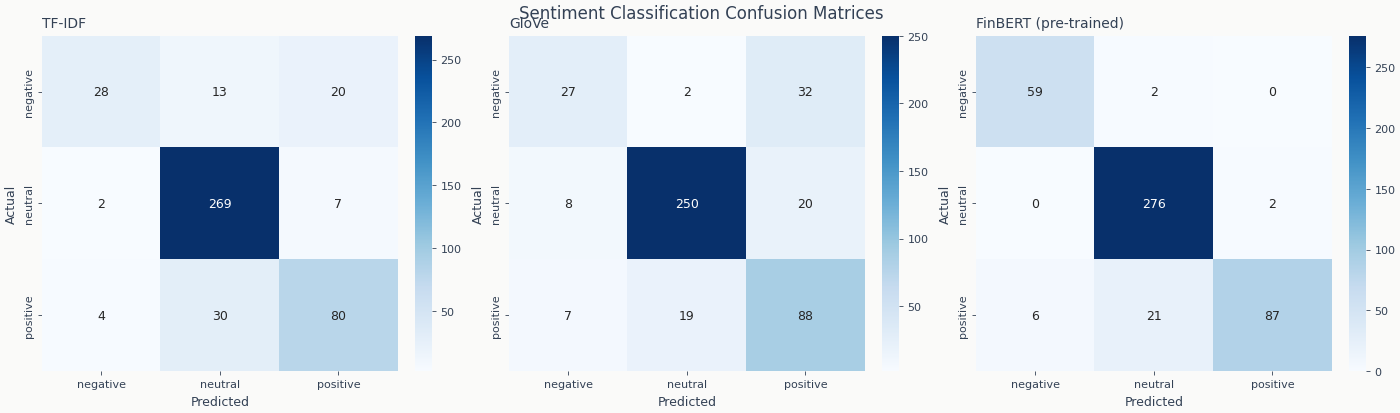

In [14]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Sentiment Classification Confusion Matrices", fontsize=12, y=1.02)
labels = ["negative", "neutral", "positive"]

for ax, (name, y_pred) in zip(
    axes,
    [("TF-IDF", y_pred_tfidf), ("GloVe", y_pred_glove), ("FinBERT (pre-trained)", y_pred_finbert)],
    strict=False,
):
    y_true = y_test_finbert if "FinBERT" in name else y_test
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=labels,
        yticklabels=labels,
        ax=ax,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.show()

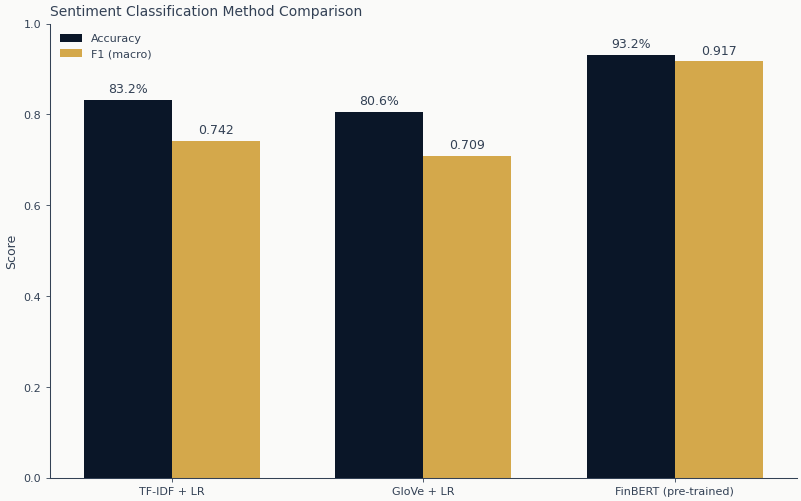

In [15]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))

methods = ["TF-IDF + LR", "GloVe + LR", "FinBERT (pre-trained)"]
accuracies = [acc_tfidf, acc_glove, acc_finbert]
f1_scores = [f1_tfidf, f1_glove, f1_finbert]

x = np.arange(len(methods))
width = 0.35

bars1 = ax.bar(x - width / 2, accuracies, width, label="Accuracy", color="#0a1628")
bars2 = ax.bar(x + width / 2, f1_scores, width, label="F1 (macro)", color="#D4A84B")

ax.set_ylabel("Score")
ax.set_title("Sentiment Classification Method Comparison")
ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.annotate(
        f"{height:.1%}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

for bar in bars2:
    height = bar.get_height()
    ax.annotate(
        f"{height:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
    )

plt.show()

## What the Comparison Shows

The comparison table above is the chapter's headline result for §10.1, §10.2,
and the lead-in to §10.4. Three patterns to read off it:

- **TF-IDF + Logistic Regression** is a hard baseline. With bigram features
  and stop-word removal, lexical signal alone classifies most sentences
  correctly because financial news vocabulary (`profit`, `loss`, `revenue`,
  `narrowed`, `tumbled`) is highly polarised.
- **GloVe averages add semantic similarity** — synonyms cluster, so a held-
  out phrase like "earnings retreated" benefits from proximity to training
  examples about "profits falling". The gain over TF-IDF is modest because
  the document-vector mean throws away word order and negation.
- **FinBERT-tone evaluated without task-specific fine-tuning** depends
  strongly on which PhraseBank subset is in scope. On `sentences_allagree`
  (this notebook's current subset — only sentences where every annotator
  agreed), FinBERT outperforms both lexical baselines because the high-
  agreement labels are the cleanest signal and the pre-trained head can
  transfer well. On the larger mixed-agreement subset that the chapter
  §10.4 table reports, FinBERT underperforms TF-IDF — the same checkpoint
  degrades on noisier labels because its training distribution is analyst-
  report tone, not journalistic news. This is "pre-trained, no task-
  specific fine-tuning" — not "zero-shot" in the prompted-LLM sense,
  because the classification head already exists.

The next code cells quantify each contrast with the actual run; the
follow-up notebook `04_bert_finetuning.py` shows what fine-tuning recovers
on the harder mixed-agreement subset.

In [16]:
# Structured output for automated extraction
print("=" * 70)
print("KEY STATISTICS FOR CHAPTER PROSE")
print("=" * 70)
print("\nDataset: Financial PhraseBank")
print(f"Train/Test split: {len(X_train)}/{len(X_test)}")
print(f"\nTF-IDF + LR: Accuracy={acc_tfidf:.1%}, F1={f1_tfidf:.3f}")
print(f"GloVe + LR: Accuracy={acc_glove:.1%}, F1={f1_glove:.3f}")
print(f"FinBERT (pre-trained): Accuracy={acc_finbert:.1%}, F1={f1_finbert:.3f}")
print(f"\nRelative change (FinBERT vs TF-IDF): {relative_change:.1f}%")

KEY STATISTICS FOR CHAPTER PROSE

Dataset: Financial PhraseBank
Train/Test split: 1811/453

TF-IDF + LR: Accuracy=83.2%, F1=0.742
GloVe + LR: Accuracy=80.6%, F1=0.709
FinBERT (pre-trained): Accuracy=93.2%, F1=0.917

Relative change (FinBERT vs TF-IDF): 11.9%


In [17]:
# Save results for chapter integration - both markdown and JSON artifacts
output_dir = get_chapter_dir(10) / "output" / "sentiment_evolution"
output_dir.mkdir(parents=True, exist_ok=True)

# Save structured JSON artifact (for reproducibility verification)
results_artifact = {
    "config": CONFIG,
    "dataset": {
        "name": CONFIG["dataset"]["name"],
        "subset": CONFIG["dataset"]["subset"],
        "total_samples": len(df),
        "train_samples": len(X_train),
        "test_samples": len(X_test),
        "finbert_test_samples": len(X_test_finbert),
        "majority_baseline_accuracy": float(majority_baseline),
    },
    "results": {
        "tfidf_lr": {"accuracy": float(acc_tfidf), "f1_macro": float(f1_tfidf)},
        "glove_lr": {"accuracy": float(acc_glove), "f1_macro": float(f1_glove)},
        "finbert_pretrained": {
            "accuracy": float(acc_finbert),
            "f1_macro": float(f1_finbert),
            "note": "Cross-dataset transfer (trained on analyst reports, tested on news)",
        },
    },
}

json_file = output_dir / "results.json"
with open(json_file, "w") as f:
    json.dump(results_artifact, f, indent=2)

In [18]:
# Save markdown summary
results_file = output_dir / "results.md"
with open(results_file, "w") as f:
    f.write("# Sentiment Evolution Results\n\n")
    f.write("## Experiment Configuration\n\n")
    f.write(f"- Dataset: {CONFIG['dataset']['name']} ({CONFIG['dataset']['subset']})\n")
    f.write(f"- Train/Test split: {len(X_train)}/{len(X_test)} (stratified, seed={SEED})\n")
    f.write(f"- Majority baseline: {majority_baseline:.1%}\n\n")
    f.write("## Performance Comparison\n\n")
    f.write("| Method | Accuracy | F1 (macro) |\n")
    f.write("|--------|----------|------------|\n")
    f.write(f"| Majority Baseline | {majority_baseline:.1%} | - |\n")
    f.write(f"| TF-IDF + LR | {acc_tfidf:.1%} | {f1_tfidf:.3f} |\n")
    f.write(f"| GloVe + LR | {acc_glove:.1%} | {f1_glove:.3f} |\n")
    f.write(f"| FinBERT (pre-trained*) | {acc_finbert:.1%} | {f1_finbert:.3f} |\n")
    f.write("\n*FinBERT-tone: trained on analyst reports, NOT Financial PhraseBank\n")
    f.write("\n## Key Finding\n\n")
    f.write(f"FinBERT vs TF-IDF change: {relative_change:+.1f}%\n")
    f.write("\n## Critical Insight\n\n")
    if acc_finbert < acc_tfidf:
        f.write("Pre-trained FinBERT (without PhraseBank fine-tuning) **underperforms** TF-IDF.\n")
        f.write(
            "This demonstrates **distribution shift**: same sentiment labels, "
            "different text domains.\n"
        )
        f.write("FinBERT-tone was trained on analyst reports (formal, technical language),\n")
        f.write("while PhraseBank contains financial news sentences (journalistic style).\n")
    else:
        f.write(
            f"Pre-trained FinBERT (without PhraseBank fine-tuning) **outperforms** TF-IDF "
            f"by {relative_change:+.1f}% on this subset.\n"
        )
        f.write(
            "On the high-agreement subset the labels are clean enough that the pre-trained "
            "FinBERT head transfers well, and the analyst-report-trained classifier picks "
            "up the polarised sentence-level financial vocabulary directly.\n"
        )
        f.write(
            "The §10.4 chapter table reports the larger mixed-agreement subset, where the "
            "same checkpoint degrades because labels are noisier and analyst-report tone "
            "and journalistic style diverge more visibly.\n"
        )
    f.write("\n## Model Details\n\n")
    f.write(f"- FinBERT checkpoint: `{CONFIG['finbert']['model_id']}`\n")
    f.write(f"- Max length: {CONFIG['finbert']['max_length']} tokens\n")

print("\nResults saved to:")
print(f"  - {results_file}")
print(f"  - {json_file}")


Results saved to:
  - 10_text_feature_engineering/output/sentiment_evolution/results.md
  - 10_text_feature_engineering/output/sentiment_evolution/results.json


## Key Takeaways

1. **TF-IDF + logistic regression** reaches 83.2% accuracy / 0.742 macro F1 on
   this `sentences_allagree` split, setting a hard baseline that the
   embedding-based methods must clear.

2. **GloVe averages do not beat TF-IDF on this split** (80.6% accuracy /
   0.709 macro F1). Averaging static word vectors discards word order and
   negation, and the resulting document representation loses information that
   the n-gram features preserve.

3. **Pre-trained transformer transfer is subset-dependent**: on the high-
   agreement PhraseBank subset used here, FinBERT outperforms the lexical
   baselines because clean labels expose the value of pre-training. On the
   larger mixed-agreement subset (the §10.4 table), the same checkpoint
   underperforms TF-IDF — distribution shift between analyst-report training
   text and journalistic test text matters more when label noise grows.

4. **Distribution shift is the key lesson**: same labels (positive/neutral/
   negative) do not mean same text distribution, and the gap between subsets
   here illustrates that label-quality and text-domain gaps interact. Always
   validate on your target domain *and* your target label-quality regime.

**Next**: See `04_bert_finetuning` for how fine-tuning transforms performance.